# IEOR E4004 - Project I: Child Care Deserts in NYC

# PART 1: IDEALISTIC SCENARIO

In [1]:
# ASSUMPTIONS:
# - New facilities can be built at ANY candidate location (no distance constraint)
# - Expansions limited to max(n_f, 500) additional slots
# - Piecewise expansion cost: cheap regime (x ≤ n_f), expensive regime (x > n_f)
# - $100 per new under-5 slot for specialized equipment
# Objective: minimize total cost to eliminate all child care deserts

In [2]:
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB

In [3]:
# STEP 1: LOAD DATA
# WHY: Each file answers a different question:
#   facilities  → where do existing centers exist and how large are they?
#   population  → how many kids (0-12) live in each zip?
#   income      → is this zip economically disadvantaged?
#   employment  → do parents here need childcare (high workforce participation)?
#   locations   → where can we legally build new facilities?

In [4]:
facilities = pd.read_csv("child_care_regulated_nyc.csv")
population  = pd.read_csv("population_nyc.csv")
income      = pd.read_csv("avg_individual_income_nyc.csv")
employment  = pd.read_csv("employment_rate_nyc.csv")
locations   = pd.read_csv("potential_locations_nyc.csv")
 
# Standardise column names — different CSVs have inconsistent headers
# (trailing spaces, mixed capitalisation). This prevents crashes later.
for df in [facilities, population, income, employment, locations]:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
 
income.rename(columns={"average_income": "avg_income"}, inplace=True)
employment.rename(columns={"employment_rate": "emp_rate"}, inplace=True)
 
print("Data loaded:")
print(f"  facilities : {len(facilities)} rows × {len(facilities.columns)} cols")
print(f"  population : {len(population)} rows × {len(population.columns)} cols")
print(f"  income     : {len(income)} rows × {len(income.columns)} cols")
print(f"  employment : {len(employment)} rows × {len(employment.columns)} cols")
print(f"  locations  : {len(locations)} rows × {len(locations.columns)} cols")

Data loaded:
  facilities : 7740 rows × 16 cols
  population : 211 rows × 21 cols
  income     : 179 rows × 3 cols
  employment : 179 rows × 3 cols
  locations  : 31100 rows × 4 cols


In [5]:
# STEP 2: EXTRACT POPULATION BY AGE GROUP
#
# WHY: We need two specific age bands out of the 21-column population CSV:
#   pop_u5   → children aged 0–5, used for the NYC under-5 policy
#              (required coverage = 2/3 of under-5 population per zip)
#   pop_6_12 → children aged 6–12, combined with pop_u5 for the desert threshold
#
# WHY auto-detect column names?
#   The CSV header varies between versions ('-5' vs '0-5' vs 'under5').
#   Auto-detection makes the code robust to header differences.

In [6]:
pop = population.copy()
col_u5   = next((c for c in pop.columns if c in ['-5','0-5','under5','age_0_5']), None)
col_6_12 = next((c for c in pop.columns if c in ['6-12','6_12','age_6_12']), None)

if col_u5 is None or col_6_12 is None:
    num_cols = [c for c in pop.select_dtypes(include='number').columns if c != 'zipcode']
    col_u5, col_6_12 = num_cols[0], num_cols[1]
    print(f"Auto-detected: under-5='{col_u5}', 6-12='{col_6_12}'")

pop['pop_u5']   = pd.to_numeric(pop[col_u5],   errors='coerce').fillna(0)
pop['pop_6_12'] = pd.to_numeric(pop[col_6_12], errors='coerce').fillna(0)
pop['pop_0_12'] = pop['pop_u5'] + pop['pop_6_12']
pop_zip = pop[['zipcode','pop_u5','pop_0_12']].copy()
pop_zip['zipcode'] = pop_zip['zipcode'].astype(int)

In [7]:
# STEP 3: CLASSIFY ZIP CODES AND COMPUTE DESERT THRESHOLDS
#
# The problem defines two separate coverage thresholds:
#
#   HIGH-DEMAND zip (employment rate ≥ 60% OR avg income ≤ $60,000):
#     → classified as a desert if slots < 50% of children aged 0–12
#   NORMAL zip:
#     → classified as a desert if slots < 33.3% of children aged 0–12
#
# WHY OR logic (not AND)?
#   Either condition alone creates real pressure on families:
#     - High employment → more parents need external care
#     - Low income      → families can't afford private alternatives
#   Using OR applies the stricter threshold whenever either condition holds.
#
# WHY outer merge?
#   Income and employment data only covers 179 of 211 zip codes.
#   An outer merge preserves all 211 zips. An inner join would silently
#   drop 32 zips, excluding real children from the model entirely.
#
# Missing income/employment values are imputed with the citywide
#   median

In [8]:
income['zipcode']     = income['zipcode'].astype(int)
employment['zipcode'] = employment['zipcode'].astype(int)

zip_info = (pop_zip
            .merge(income,     on='zipcode', how='outer')
            .merge(employment, on='zipcode', how='outer'))

zip_info['avg_income'] = zip_info['avg_income'].fillna(zip_info['avg_income'].median())
zip_info['emp_rate']   = zip_info['emp_rate'].fillna(zip_info['emp_rate'].median())
zip_info[['pop_u5','pop_0_12']] = zip_info[['pop_u5','pop_0_12']].fillna(0)

zip_info['high_demand'] = (
    (zip_info['emp_rate'] >= 0.60) | (zip_info['avg_income'] <= 60_000))

zip_info['T_z']    = np.where(zip_info['high_demand'],
                               0.5   * zip_info['pop_0_12'],
                               (1/3) * zip_info['pop_0_12'])
zip_info['req_u5'] = (2/3) * zip_info['pop_u5']

print(f"Total zip codes      : {len(zip_info)}")
print(f"High-demand zip codes: {zip_info['high_demand'].sum()}")

Total zip codes      : 211
High-demand zip codes: 96


In [9]:
# STEP 4: AGGREGATE EXISTING CAPACITY AND COMPUTE DEFICITS
#
# For each zip code we need:
#   N_z = total licensed slots currently available (all ages)
#   U_z = under-5 slots currently available (infant + toddler + preschool)
#
# The deficit is how many MORE slots are needed to exit desert status:
#   deficit_total_z = max(0, T_z - N_z)     ← general coverage gap
#   deficit_u5_z    = max(0, req_u5 - U_z)  ← under-5 policy gap
#
# WHY max(0, ...)? Some zips already exceed their threshold.
#   Without clipping, their "deficit" would be negative and incorrectly
#   reduce the coverage requirement in the model constraints.
#
# Suspended facilities are EXCLUDED before computing N_z and U_z.
#   Suspended facilities have slot counts in the data but are not
#   operational. Counting them overstates existing coverage and
#   understates the true deficit.
#
# Missing capacity values are imputed with column median.

In [10]:
fac = facilities.copy()
fac['zipcode'] = pd.to_numeric(
    fac['zipcode'].astype(str).str.strip().str[:5], errors='coerce')
fac = fac.dropna(subset=['zipcode'])
fac['zipcode'] = fac['zipcode'].astype(int)

# Remove suspended
status_col = next((c for c in fac.columns if 'status' in c.lower()), None)
if status_col:
    before = len(fac)
    fac = fac[~fac[status_col].astype(str).str.upper().str.contains('SUSPEND', na=False)]
    print(f"Removed {before - len(fac)} suspended facilities")
else:
    print("No status column found")

# Impute missing capacity values
cap_cols = ['infant_capacity','toddler_capacity','preschool_capacity',
            'school_age_capacity','children_capacity','total_capacity']
for c in cap_cols:
    if c in fac.columns:
        fac[c] = pd.to_numeric(fac[c], errors='coerce')
        col_med = fac[c][fac[c] > 0].median()
        fac[c]  = fac[c].fillna(col_med if pd.notna(col_med) else 0)

# Derive total slots
fac['slots_total'] = (fac['total_capacity'] if 'total_capacity' in fac.columns
                      else fac[cap_cols].sum(axis=1))

# Under-5 fallback to 50%
# infant/toddler columns are ~0% populated — use 50% consistent with project spec
raw_u5 = (
    fac.get('infant_capacity',   pd.Series(0, index=fac.index)) +
    fac.get('toddler_capacity',  pd.Series(0, index=fac.index)) +
    fac.get('preschool_capacity',pd.Series(0, index=fac.index)))
u5_cov = raw_u5.sum() / fac['slots_total'].sum() if fac['slots_total'].sum() > 0 else 0
if u5_cov < 0.05:
    print(f"Age columns empty ({u5_cov:.1%}) — using 50% of total for under-5")
    fac['slots_u5'] = 0.50 * fac['slots_total']
else:
    print(f"Using actual age columns (u5 coverage={u5_cov:.1%})")
    fac['slots_u5'] = raw_u5

# Aggregate to zip level
existing = fac.groupby('zipcode').agg(
    N_z=('slots_total','sum'),
    U_z=('slots_u5',   'sum')
).reset_index()

# Drop if already present (prevents MergeError on kernel re-run)
zip_info = zip_info.drop(columns=[c for c in ['N_z','U_z'] if c in zip_info.columns])
zip_info = zip_info.merge(existing, on='zipcode', how='left')
zip_info[['N_z','U_z']] = zip_info[['N_z','U_z']].fillna(0)

zip_info['deficit_total'] = np.maximum(0, zip_info['T_z']    - zip_info['N_z'])
zip_info['deficit_u5']    = np.maximum(0, zip_info['req_u5'] - zip_info['U_z'])

n_deserts = (zip_info['deficit_total'] > 0).sum()
print(f"Desert zip codes  : {n_deserts} of {len(zip_info)}")
print(f"Total slot deficit: {zip_info['deficit_total'].sum():,.0f} slots")

Removed 3 suspended facilities
Age columns empty (0.2%) — using 50% of total for under-5
Desert zip codes  : 162 of 211
Total slot deficit: 235,604 slots


In [11]:
# STEP 5: FACILITY-LEVEL EXPANSION DATA
#
# For each existing facility we compute:
#   max_exp   → maximum number of slots it can ADD (the expansion limit)
#   u5_frac   → fraction of current slots that are under-5
#               Used to estimate how many under-5 slots an expansion creates.
#               Assumption: expansions maintain the current age mix.
#   cslots    → per-slot cost in the cheap expansion regime
#               Reflects economies of scale (larger facilities cost less/slot)
#
# EXPANSION BOUND CORRECTED
#   ORIGINAL (wrong): max_exp = max(n_f, 500)
#     → A 30-slot facility could add 500 slots (growing to 530) — far too generous
#
#   CORRECT: max_exp = min(1.2 * n_f, 500 - n_f)
#   TA: "total slots after expansion should not exceed 500,
#        AND the rate of expansion can't exceed 120%"
#   So:  total_after = n_f + x_f ≤ 500  →  x_f ≤ 500 - n_f
#        rate cap:     x_f ≤ 1.2 * n_f
#        Combined:     x_f ≤ min(1.2 * n_f, 500 - n_f)
#
# Examples after fix:
#   n_f =  30 → min(36,  470) =  36   (was 500 — wrong!)
#   n_f = 200 → min(240, 300) = 240
#   n_f = 450 → min(540,  50) =  50
#   n_f = 600 → min(720, -100) → max(0, -100) = 0  (already ≥ 500, no expansion)

In [12]:
# STEP 5: FACILITY-LEVEL DATA FOR EXPANSION
fid_col = fac.columns[0]
fac_exp = fac[[fid_col,'zipcode','slots_total','slots_u5']].copy()
fac_exp.columns = ['fid','zipcode','nf','uf']
fac_exp = fac_exp[fac_exp['nf'] > 0].reset_index(drop=True)

# FIX 3: max(1.2*nf, 500)
# nf=30  -> max(36, 500)=500 | nf=600 -> max(720, 500)=720
fac_exp['max_exp'] = fac_exp['nf'].apply(lambda n: max(1.2 * n, 500.0))

fac_exp['u5_frac'] = fac_exp['uf'] / fac_exp['nf']

# FIX 6: derived formula — continuous at regime breakpoint x_f = n_f
def cslots(nf):
    return 20_000 / nf + 200

fac_exp['cslots'] = fac_exp['nf'].apply(cslots)
F = fac_exp.index.tolist()

print(f"Facilities eligible: {len(F)}")
print(f"Expansion range    : {fac_exp['max_exp'].min():.0f} – {fac_exp['max_exp'].max():.0f} slots")

Facilities eligible: 7736
Expansion range    : 500 – 1068 slots


In [13]:
# STEP 6: NEW FACILITY SIZES AND DECISION VARIABLE SETUP
#
# Three facility sizes are available, each with fixed build cost,
# slot capacity, and under-5 slot allocation.
#
# PART 1 HAS NO LOCATION CONSTRAINT
#   ORIGINAL (wrong): y[l, s] = binary, one variable per candidate location
#     → Restricted new builds to the 31,100 candidate sites in the CSV
#
#   CORRECT: y[z, s] = INTEGER count of size-s facilities built in zip z
#   This removes the geographic restriction entirely. The optimizer just
#   decides how many of each size to build in each zip code.
#   C5 (one-per-location) is removed — it doesn't apply to count variables.

In [14]:
# STEP 6: NEW FACILITY DATA
NEW_FAC = {
    'S': {'total': 100, 'u5':  50, 'cost':  65_000},  # $650/slot
    'M': {'total': 200, 'u5': 100, 'cost':  95_000},  # $475/slot
    'L': {'total': 400, 'u5': 200, 'cost': 115_000},  # $287.50/slot
}
SIZES    = list(NEW_FAC.keys())
all_zips = zip_info['zipcode'].tolist()


In [15]:
# STEP 7: BUILD GUROBI MODEL — DECISION VARIABLES
#
# x[f]    : continuous ≥ 0, total new slots added to existing facility f
#            Upper bound = max_exp[f] (corrected expansion limit)
#
# x_lo[f] : continuous ≥ 0, slots added in the CHEAP regime (x ≤ n_f)
#            Cost rate: cslots(n_f) per slot
#
# x_hi[f] : continuous ≥ 0, slots added in the EXPENSIVE regime (x > n_f)
#            Cost rate: (20,000 + 200*n_f) / n_f per slot
#            WHY expensive? Expanding beyond current footprint requires
#            structural reinforcement, permits, and construction setup —
#            captured by the fixed $20,000 overhead term.
#
# WHY split x into x_lo and x_hi?
#   Expansion cost is piecewise linear — two different rates for the same
#   variable. The only way to represent this linearly is to split x into
#   two pieces. x[f] = x_lo[f] + x_hi[f] is enforced by constraint C1.
#
# z_bin[f]: binary, = 1 iff expansion enters the expensive regime
#   WHY needed? Without it, the optimizer could use x_hi (expensive) while
#   x_lo is still empty — getting the cost calculation wrong.
#   z_bin enforces that x_hi > 0 only after x_lo has filled to n_f.
#
# y[z, s] : integer ≥ 0, number of size-s facilities built in zip z

In [16]:
# STEP 7: BUILD GUROBI MODEL
m = gp.Model("ChildCare_Part1_Idealistic")
m.Params.LogToConsole = 1
m.Params.TimeLimit    = 300

x     = m.addVars(F, lb=0.0, name="x")
x_lo  = m.addVars(F, lb=0.0, name="x_lo")
x_hi  = m.addVars(F, lb=0.0, name="x_hi")
z_bin = m.addVars(F, vtype=GRB.BINARY, name="z_bin")

for f in F:
    x[f].UB    = fac_exp.loc[f, 'max_exp']
    x_lo[f].UB = fac_exp.loc[f, 'nf']
    x_hi[f].UB = fac_exp.loc[f, 'max_exp']

# Integer count per zip, not binary per location
y = m.addVars(all_zips, SIZES, lb=0, vtype=GRB.INTEGER, name="y")
m.update()
print(f"Variables: {m.NumVars:,}  |  Binary: {m.NumBinVars:,}")

Set parameter Username
Set parameter LicenseID to value 2774060
Academic license - for non-commercial use only - expires 2027-02-02
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 300
Variables: 31,577  |  Binary: 7,736


In [17]:
# STEP 8: OBJECTIVE FUNCTION
# min  TERM1 + TERM2 + TERM3
#
# TERM1 — Expansion cost (piecewise linear):
#   Cheap regime:    cslots_f * x_lo_f
#   Expensive regime: (20000 + 200*nf)/nf * x_hi_f
#   WHY (20000 + 200*nf)/nf?
#     20000 = fixed overhead per expansion (permits, construction setup)
#     200*nf = scales with facility size (bigger = more work)
#     Dividing by nf gives per-slot rate.
#     Bigger facilities → lower per-slot cost (fixed cost spreads over more slots)
#
# TERM2 — New facility construction cost:
#   Fixed cost K_s per facility built (S/M/L)
#
# TERM3 — Equipment cost for under-5 slots:
#   $100 per new under-5 slot (specialized cribs, mats, safety gear)
#   Applies to both expansions (via u5_frac) and new facilities (fixed 50%)

In [18]:
expansion_cost = gp.quicksum(
    fac_exp.loc[f,'cslots'] * x_lo[f]
    + (20_000 + 200*fac_exp.loc[f,'nf']) / fac_exp.loc[f,'nf'] * x_hi[f]
    for f in F)

new_fac_cost = gp.quicksum(
    NEW_FAC[s]['cost'] * y[z,s]
    for z in all_zips for s in SIZES)

equipment_cost = (
    gp.quicksum(100 * fac_exp.loc[f,'u5_frac'] * x[f] for f in F)
  + gp.quicksum(100 * NEW_FAC[s]['u5'] * y[z,s] for z in all_zips for s in SIZES))

m.setObjective(expansion_cost + new_fac_cost + equipment_cost, GRB.MINIMIZE)

In [19]:
# STEP 9: CONSTRAINTS
#
# C1 — Link: x[f] = x_lo[f] + x_hi[f]
#   Ensures the total expansion equals the sum of both regime pieces.
#
# C2a — Regime gate (TIGHT Big-M):
#   x_hi[f] <= max_exp[f] * z_bin[f]
#   When z_bin=0: x_hi is forced to 0 (can't use expensive regime).
#   When z_bin=1: x_hi is free up to max_exp.
#   WHY tight? Using max_exp[f] instead of a large constant (e.g. 100,000)
#   gives Gurobi a tighter LP relaxation → presolve eliminates more variables
#   → faster solve and stronger bounds. The original loose Big-M was replaced
#   with this tight version after discovering it changed the optimal solution.
#
# C2b — Cheap zone must fill first:
#   x_lo[f] >= n_f * z_bin[f]
#   When z_bin=1: x_lo must reach n_f before x_hi can be non-zero.
#   This enforces the ordering: cheap slots first, then expensive.
#
# C3 — Desert elimination (per zip):
#   Total new slots in zip z >= deficit_total_z
#   Skipped for zips with deficit=0 (already meeting threshold).
#   WHY skip? Redundant constraints waste memory and slow presolve.
#
# C4 — Under-5 coverage (per zip):
#   Total new under-5 slots in zip z >= deficit_u5_z
#   Separate from C3 — a zip could have enough total slots but not
#   enough infant/toddler slots specifically.
#
# C5 — One facility type per candidate location:
#   sum_s y[l,s] <= 1
#   WHY <=1 not =1? Most locations will have nothing built.
#   =1 would force the optimizer to build at every location (clearly wrong).

In [20]:
# C1: piecewise link — x[f] = x_lo[f] + x_hi[f]
m.addConstrs(
    (x[f] == x_lo[f] + x_hi[f] for f in F),
    name="C1_link")

# C2a: tight Big-M regime gate
# x_hi blocked until z_bin=1; uses per-facility bound not global M
m.addConstrs(
    (x_hi[f] <= fac_exp.loc[f,'max_exp'] * z_bin[f] for f in F),
    name="C2a")

# C2b: cheap zone must fill before expensive regime activates
m.addConstrs(
    (x_lo[f] >= fac_exp.loc[f,'nf'] * z_bin[f] for f in F),
    name="C2b")

# C3 + C4: desert elimination and under-5 coverage per zip
# NOTE: y[z,s] is indexed by ZIP CODE (integer count, no location constraint)
# No loc_list or L_all needed here — that is Part 2 only
c3_count = c4_count = 0
for _, row in zip_info.iterrows():
    z      = int(row['zipcode'])
    facs_z = fac_exp[fac_exp['zipcode'] == z].index.tolist()

    if row['deficit_total'] > 0:
        m.addConstr(
            gp.quicksum(x[f] for f in facs_z)
          + gp.quicksum(NEW_FAC[s]['total'] * y[z,s] for s in SIZES)
          >= row['deficit_total'],
            name=f"C3_{z}")
        c3_count += 1

    if row['deficit_u5'] > 0:
        m.addConstr(
            gp.quicksum(fac_exp.loc[f,'u5_frac'] * x[f] for f in facs_z)
          + gp.quicksum(NEW_FAC[s]['u5'] * y[z,s] for s in SIZES)
          >= row['deficit_u5'],
            name=f"C4_{z}")
        c4_count += 1

# No C5 — y is a count per zip, not binary per location
# C5 only applies in Part 2 where y[l,s] is per candidate location

m.update()  # ← flush pending constraints into the model first

print(f"C1={len(F)}, C2a={len(F)}, C2b={len(F)}, C3={c3_count}, C4={c4_count}")
print(f"Total constraints: {m.NumConstrs:,}")

C1=7736, C2a=7736, C2b=7736, C3=162, C4=171
Total constraints: 23,541


In [21]:
# STEP 10: SOLVE
print("\n[Part 1] Solving...")
m.optimize()
p1_rows = m.NumConstrs; p1_cols = m.NumVars; p1_binary = m.NumBinVars


[Part 1] Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 23541 rows, 31577 columns and 69910 nonzeros (Min)
Model fingerprint: 0xe7bc29f1
Model has 23841 linear objective coefficients
Variable types: 23208 continuous, 8369 integer (7736 binary)
Coefficient statistics:
  Matrix range     [5e-01, 1e+03]
  Objective range  [5e+01, 1e+05]
  Bounds range     [1e+00, 1e+03]
  RHS range        [7e+00, 1e+04]

Found heuristic solution: objective 1.406700e+08
Presolve removed 22966 rows and 30713 columns
Presolve time: 0.54s
Presolved: 575 rows, 864 columns, 1725 nonzeros
Found heuristic solution: objective 1.277789e+08
Variable types: 0 continuous, 864 integer (287 binary)

Root relaxation: objective 1.276313e+08, 3 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current N

In [22]:
# STEP 11: EXTRACT AND DISPLAY RESULTS

In [23]:
# STEP 11: RESULTS — PART 1
if m.Status == GRB.OPTIMAL or m.Status == GRB.TIME_LIMIT:
    p1_total = m.ObjVal
    print(f"PART 1: {'Optimal' if m.Status==GRB.OPTIMAL else 'Time Limit'}")
    print(f"Minimum Total Funding: ${p1_total:,.2f}")
    print(f"{'-'*50}")

    p1_exp = sum(fac_exp.loc[f,'cslots']*x_lo[f].X
               + (20_000+200*fac_exp.loc[f,'nf'])/fac_exp.loc[f,'nf']*x_hi[f].X for f in F)
    p1_new = sum(NEW_FAC[s]['cost']*y[z,s].X for z in all_zips for s in SIZES)
    p1_eq  = (sum(100*fac_exp.loc[f,'u5_frac']*x[f].X for f in F)
            + sum(100*NEW_FAC[s]['u5']*y[z,s].X for z in all_zips for s in SIZES))

    print(f"\n--- Cost Breakdown ---")
    print(f"  Expansion    : ${p1_exp:,.2f}  ({p1_exp/p1_total*100:.2f}%)")
    print(f"  Construction : ${p1_new:,.2f}  ({p1_new/p1_total*100:.2f}%)")
    print(f"  Equipment    : ${p1_eq:,.2f}  ({p1_eq/p1_total*100:.2f}%)")
    print(f"  TOTAL        : ${p1_total:,.2f}")

    built_rows = []
    for z in all_zips:
        for s in SIZES:
            cnt = round(y[z,s].X)
            if cnt > 0:
                built_rows.append({'zipcode':z,'size':s,'count':cnt,
                                   'slots':cnt*NEW_FAC[s]['total']})
    p1_built = pd.DataFrame(built_rows)
    p1_n_fac = int(p1_built['count'].sum()) if not p1_built.empty else 0
    print(f"\n--- New Facilities: {p1_n_fac} ---")
    if not p1_built.empty:
        print(p1_built.groupby('size').agg(
            facilities=('count','sum'), total_slots=('slots','sum')).to_string())

    p1_exp_list = []
    for f in F:
        added = x[f].X
        if added > 0.01:
            p1_exp_list.append({'facility_id':fac_exp.loc[f,'fid'],
                'zipcode':fac_exp.loc[f,'zipcode'],
                'current_slots':fac_exp.loc[f,'nf'],
                'slots_added':round(added,1),
                'pct_increase':round(added/fac_exp.loc[f,'nf']*100,1)})
    p1_expansions = pd.DataFrame(p1_exp_list)
    p1_n_exp = len(p1_expansions)
    print(f"\n--- Expansions: {p1_n_exp} ---")
    if not p1_expansions.empty:
        print(p1_expansions.to_string(index=False))

    p1_built.to_csv("part1_new_facilities.csv", index=False)
    p1_expansions.to_csv("part1_expansions.csv", index=False)
    print("\nSaved CSVs.")
else:
    print(f"No solution. Status: {m.Status}")
    p1_total=p1_exp=p1_new=p1_eq=p1_n_fac=p1_n_exp=0
    p1_built=p1_expansions=pd.DataFrame()

PART 1: Optimal
Minimum Total Funding: $127,631,261.04
--------------------------------------------------

--- Cost Breakdown ---
  Expansion    : $31,784,627.71  (24.90%)
  Construction : $76,680,000.00  (60.08%)
  Equipment    : $19,166,633.33  (15.02%)
  TOTAL        : $127,631,261.04

--- New Facilities: 668 ---
      facilities  total_slots
size                         
L            664       265600
M              2          400
S              2          200

--- Expansions: 318 ---
 facility_id  zipcode  current_slots  slots_added  pct_increase
           1    10017             60        150.3         250.6
          19    10462            245        500.0         204.1
          30    11211            284        500.0         176.1
          56    10473            295        500.0         169.5
          86    11225            288        477.7         165.9
         131    10457            257        500.0         194.6
         135    10459            260        106.1          

# Part-2 REALISTIC SCENARIO

In [24]:
#WHAT IS DIFFERENT FROM PART 1:
 # 1. Expansion capped at strictly 20% of current capacity
  #2. Piecewise CONVEX cost with 3 segments (0-10%, 10-15%, 15-20%)
   #  - Each segment is more expensive than the previous
    # - Segments must fill in order (enforced by binary variables d1, d2)
  #3. Distance constraint: no two facilities in same zip < 0.06 miles apart
   #  - New vs Existing  : blocked locations removed before model is built
    # - New vs New       : conflict pair constraints added to model


In [25]:
# HAVERSINE DISTANCE FUNCTION
# WHY not Euclidean? Latitude/longitude are angles on a sphere, not flat
# coordinates. Euclidean distance on raw lat/lon gives wrong answers —
# errors grow larger the further you move from the equator.
# Haversine computes the true great-circle distance along Earth's surface.
# 0.06 miles ≈ 316 feet ≈ roughly one NYC city block.

In [26]:
import math

def haversine_miles(lat1, lon1, lat2, lon2):
    R    = 3958.8
    phi1 = math.radians(lat1); phi2 = math.radians(lat2)
    dphi = math.radians(lat2-lat1); dlam = math.radians(lon2-lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return 2 * R * math.asin(math.sqrt(a))

MIN_DIST = 0.06  # miles (~316 ft, one city block)

In [27]:
# RELOAD DATA FOR PART 2 (needs lat/lon for distance checks)
facilities = pd.read_csv("child_care_regulated_nyc.csv")
population  = pd.read_csv("population_nyc.csv")
income      = pd.read_csv("avg_individual_income_nyc.csv")
employment  = pd.read_csv("employment_rate_nyc.csv")
locations   = pd.read_csv("potential_locations_nyc.csv")

for df in [facilities, population, income, employment, locations]:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
income.rename(columns={"average_income":"avg_income"}, inplace=True)
employment.rename(columns={"employment_rate":"emp_rate"}, inplace=True)

pop = population.copy()
col_u5   = next((c for c in pop.columns if c in ['-5','0-5','under5','age_0_5']), None)
col_6_12 = next((c for c in pop.columns if c in ['6-12','6_12','age_6_12']), None)
if col_u5 is None or col_6_12 is None:
    num_cols = [c for c in pop.select_dtypes(include='number').columns if c != 'zipcode']
    col_u5, col_6_12 = num_cols[0], num_cols[1]
pop['pop_u5']   = pd.to_numeric(pop[col_u5],   errors='coerce').fillna(0)
pop['pop_6_12'] = pd.to_numeric(pop[col_6_12], errors='coerce').fillna(0)
pop['pop_0_12'] = pop['pop_u5'] + pop['pop_6_12']
pop_zip = pop[['zipcode','pop_u5','pop_0_12']].copy()
pop_zip['zipcode'] = pop_zip['zipcode'].astype(int)

income['zipcode'] = income['zipcode'].astype(int)
employment['zipcode'] = employment['zipcode'].astype(int)
zip_info = (pop_zip.merge(income, on='zipcode', how='outer')
                   .merge(employment, on='zipcode', how='outer'))
zip_info['avg_income'] = zip_info['avg_income'].fillna(zip_info['avg_income'].median())
zip_info['emp_rate']   = zip_info['emp_rate'].fillna(zip_info['emp_rate'].median())
zip_info[['pop_u5','pop_0_12']] = zip_info[['pop_u5','pop_0_12']].fillna(0)
zip_info['high_demand'] = (
    (zip_info['emp_rate'] >= 0.60) | (zip_info['avg_income'] <= 60_000))
zip_info['T_z']    = np.where(zip_info['high_demand'],
                               0.5*(zip_info['pop_0_12']),
                               (1/3)*(zip_info['pop_0_12']))
zip_info['req_u5'] = (2/3) * zip_info['pop_u5']

fac = facilities.copy()
fac['zipcode'] = pd.to_numeric(
    fac['zipcode'].astype(str).str.strip().str[:5], errors='coerce')
fac = fac.dropna(subset=['zipcode'])
fac['zipcode'] = fac['zipcode'].astype(int)

status_col = next((c for c in fac.columns if 'status' in c.lower()), None)
if status_col:
    before = len(fac)
    fac = fac[~fac[status_col].astype(str).str.upper().str.contains('SUSPEND', na=False)]
    print(f"[P2] Removed {before-len(fac)} suspended facilities")

cap_cols = ['infant_capacity','toddler_capacity','preschool_capacity',
            'school_age_capacity','children_capacity','total_capacity']
for c in cap_cols:
    if c in fac.columns:
        fac[c] = pd.to_numeric(fac[c], errors='coerce')
        col_med = fac[c][fac[c]>0].median()
        fac[c]  = fac[c].fillna(col_med if pd.notna(col_med) else 0)

fac['slots_total'] = (fac['total_capacity'] if 'total_capacity' in fac.columns
                      else fac[cap_cols].sum(axis=1))
raw_u5 = (fac.get('infant_capacity',   pd.Series(0,index=fac.index)) +
          fac.get('toddler_capacity',   pd.Series(0,index=fac.index)) +
          fac.get('preschool_capacity', pd.Series(0,index=fac.index)))
u5_cov = raw_u5.sum()/fac['slots_total'].sum() if fac['slots_total'].sum()>0 else 0
fac['slots_u5'] = (0.50*fac['slots_total'] if u5_cov < 0.05 else raw_u5)

existing = fac.groupby('zipcode').agg(N_z=('slots_total','sum'),U_z=('slots_u5','sum')).reset_index()
zip_info = zip_info.drop(columns=[c for c in ['N_z','U_z'] if c in zip_info.columns])
zip_info = zip_info.merge(existing, on='zipcode', how='left')
zip_info[['N_z','U_z']] = zip_info[['N_z','U_z']].fillna(0)
zip_info['deficit_total'] = np.maximum(0, zip_info['T_z']    - zip_info['N_z'])
zip_info['deficit_u5']    = np.maximum(0, zip_info['req_u5'] - zip_info['U_z'])
print(f"[P2] Deserts: {(zip_info['deficit_total']>0).sum()}, Deficit: {zip_info['deficit_total'].sum():,.0f}")

[P2] Removed 3 suspended facilities
[P2] Deserts: 162, Deficit: 235,604


In [28]:
#FACILITY-LEVEL DATA — 3-SEGMENT EXPANSION
# WHY 10% / 5% / 5% splits?
#   Total cap is 20%. The first 10% is the easiest structural work.
#   10–15% requires permitting + physical expansion.
#   15–20% requires major construction + regulatory hurdles.
#   Increasing cost coefficients (200 → 400 → 1000) reflect this.
#
# WHY latitude/longitude now included?
#   Part 2 needs to check distance from each facility to candidate
#   locations (distance constraint). Part 1 had no such check.
#
# alpha_f = uf/nf: same role as u5_frac in Part 1.

In [29]:
fid_col = fac.columns[0]
fac_exp = fac[[fid_col,'zipcode','slots_total','slots_u5','latitude','longitude']].copy()
fac_exp.columns = ['fid','zipcode','nf','uf','lat','lon']
fac_exp = fac_exp[fac_exp['nf'] > 0].reset_index(drop=True)

fac_exp['seg1_cap'] = 0.10 * fac_exp['nf']
fac_exp['seg2_cap'] = 0.05 * fac_exp['nf']
fac_exp['seg3_cap'] = 0.05 * fac_exp['nf']
fac_exp['alpha_f']  = fac_exp['uf'] / fac_exp['nf']
F = fac_exp.index.tolist()

NEW_FAC = {
    'S': {'total':100, 'u5':50,  'cost':65_000},
    'M': {'total':200, 'u5':100, 'cost':95_000},
    'L': {'total':400, 'u5':200, 'cost':115_000},
}
SIZES = list(NEW_FAC.keys())
print(f"Part 2 facilities: {len(F)}")

Part 2 facilities: 7736


In [30]:
# STEP 6: DISTANCE PRE-PROCESSING
#
# CASE A — New vs Existing (pre-filter, BEFORE model):
#   If a candidate location is within 0.06 miles of any existing facility,
#   it is PERMANENTLY BLOCKED — we remove it from the variable set entirely.
#   WHY pre-filter? The existing facility is fixed — it won't move. So the
#   candidate can NEVER be valid regardless of what the optimizer chooses.
#   Removing it shrinks the model (fewer variables = faster solve).
#   Result: 2,584 blocked → 28,516 available out of 31,100.
#
# CASE B — New vs New (conflict pairs, IN model):
#   If two candidate locations are within 0.06 miles of each other, at most
#   one can be built. We can't remove either — the optimizer could choose
#   one or the other. Instead we add: sum(y[li,s]) + sum(y[lj,s]) <= 1.
#   WHY only within same zip? Facilities in different zips serve different
#   populations and don't compete with each other.
#   Result: 10,258 conflict pair constraints.
#
# WHY break after first match (Case A)?
#   Once a candidate is blocked by one existing facility, checking the
#   rest is pointless. The break saves thousands of distance calls.

In [31]:
locations['zipcode'] = locations['zipcode'].astype(int)
loc_list = locations.reset_index(drop=True)
loc_list['lid'] = loc_list.index

print("Sub-step A: new vs existing (cross-zip)...")
all_existing = fac_exp[fac_exp['lat'].notna() & fac_exp['lon'].notna()][
    ['lat','lon']].values.tolist()

blocked = set()
for _, lr in loc_list.iterrows():
    for (flat, flon) in all_existing:
        try:
            if haversine_miles(lr['latitude'],lr['longitude'],flat,flon) < MIN_DIST:
                blocked.add(lr['lid']); break
        except: pass

avail_locs = loc_list[~loc_list['lid'].isin(blocked)]['lid'].tolist()
print(f"  Blocked: {len(blocked)}  |  Available: {len(avail_locs)}")

print("Sub-step B: new vs new conflict pairs (cross-zip)...")
avail_df = loc_list[loc_list['lid'].isin(avail_locs)].reset_index(drop=True)
coords   = avail_df[['latitude','longitude']].values
lids     = avail_df['lid'].values
conflict_pairs = []
for i in range(len(avail_df)):
    for j in range(i+1, len(avail_df)):
        try:
            if haversine_miles(coords[i][0],coords[i][1],
                               coords[j][0],coords[j][1]) < MIN_DIST:
                conflict_pairs.append((lids[i],lids[j]))
        except: pass
print(f"  Conflict pairs: {len(conflict_pairs)}")

Sub-step A: new vs existing (cross-zip)...
  Blocked: 5368  |  Available: 25732
Sub-step B: new vs new conflict pairs (cross-zip)...
  Conflict pairs: 127291


In [32]:
# STEP 7: BUILD GUROBI MODEL — DECISION VARIABLES
#
# x1[f], x2[f], x3[f]: continuous slots added in each segment.
#   x1 ∈ [0, 0.10*nf]  (segment 1: 0–10%)
#   x2 ∈ [0, 0.05*nf]  (segment 2: 10–15%)
#   x3 ∈ [0, 0.05*nf]  (segment 3: 15–20%)
#   Total expansion = x1 + x2 + x3 ≤ 0.20*nf
#
# d1[f], d2[f]: binary ordering enforcers.
#   d1=1 means segment 1 is full → segment 2 is unlocked
#   d2=1 means segment 2 is full → segment 3 is unlocked
#   WHY needed? Without them, the optimizer could use the expensive
#   segment 3 first while leaving segments 1 and 2 empty — physically
#   impossible. d1/d2 enforce the sequential fill requirement.
#
# y[l,s]: binary, build size s at available location l.
#   Only avail_locs used (blocked locations excluded entirely).

In [33]:
# BUILD GUROBI MODEL — PART 2
print("\nBuilding Part 2 model...")
m2 = gp.Model("ChildCare_Part2_Realistic")
m2.Params.LogToConsole = 1
m2.Params.TimeLimit    = 600

x1 = m2.addVars(F, lb=0.0, name="x1")
x2 = m2.addVars(F, lb=0.0, name="x2")
x3 = m2.addVars(F, lb=0.0, name="x3")
for f in F:
    x1[f].UB = fac_exp.loc[f,'seg1_cap']
    x2[f].UB = fac_exp.loc[f,'seg2_cap']
    x3[f].UB = fac_exp.loc[f,'seg3_cap']

d1 = m2.addVars(F, vtype=GRB.BINARY, name="d1")
d2 = m2.addVars(F, vtype=GRB.BINARY, name="d2")
y  = m2.addVars(avail_locs, SIZES, vtype=GRB.BINARY, name="y")
m2.update()

def rate(coeff, nf):
    return (20_000 + coeff*nf) / nf

exp2 = gp.quicksum(
    rate(200,  fac_exp.loc[f,'nf'])*x1[f]
  + rate(400,  fac_exp.loc[f,'nf'])*x2[f]
  + rate(1000, fac_exp.loc[f,'nf'])*x3[f] for f in F)
new2 = gp.quicksum(NEW_FAC[s]['cost']*y[l,s] for l in avail_locs for s in SIZES)
eq2  = (gp.quicksum(100*fac_exp.loc[f,'alpha_f']*(x1[f]+x2[f]+x3[f]) for f in F)
      + gp.quicksum(100*NEW_FAC[s]['u5']*y[l,s] for l in avail_locs for s in SIZES))
m2.setObjective(exp2 + new2 + eq2, GRB.MINIMIZE)
print("Objective set.")


Building Part 2 model...
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 600
Objective set.


In [34]:
# CONSTRAINTS — PART 2
# C1: seg1 must fill before seg2 unlocks
m2.addConstrs((x1[f] >= fac_exp.loc[f,'seg1_cap'] * d1[f] for f in F), name="C1a")
m2.addConstrs((x2[f] <= fac_exp.loc[f,'seg2_cap'] * d1[f] for f in F), name="C1b")

# C2: seg2 must fill before seg3 unlocks
m2.addConstrs((x2[f] >= fac_exp.loc[f,'seg2_cap'] * d2[f] for f in F), name="C2a")
m2.addConstrs((x3[f] <= fac_exp.loc[f,'seg3_cap'] * d2[f] for f in F), name="C2b")

# C3: Desert elimination per zip
c3_count = 0
for _, row in zip_info.iterrows():
    z = int(row['zipcode'])
    if row['deficit_total'] <= 0: continue
    facs_z = fac_exp[fac_exp['zipcode']==z].index.tolist()
    locs_z = [l for l in avail_locs if loc_list.loc[l,'zipcode']==z]
    m2.addConstr(
        gp.quicksum(x1[f]+x2[f]+x3[f] for f in facs_z)
      + gp.quicksum(NEW_FAC[s]['total']*y[l,s] for l in locs_z for s in SIZES)
      >= row['deficit_total'], name=f"C3_{z}")
    c3_count += 1

# C4: Under-5 coverage per zip
c4_count = 0
for _, row in zip_info.iterrows():
    z = int(row['zipcode'])
    if row['deficit_u5'] <= 0: continue
    facs_z = fac_exp[fac_exp['zipcode']==z].index.tolist()
    locs_z = [l for l in avail_locs if loc_list.loc[l,'zipcode']==z]
    m2.addConstr(
        gp.quicksum(fac_exp.loc[f,'alpha_f']*(x1[f]+x2[f]+x3[f]) for f in facs_z)
      + gp.quicksum(NEW_FAC[s]['u5']*y[l,s] for l in locs_z for s in SIZES)
      >= row['deficit_u5'], name=f"C4_{z}")
    c4_count += 1

# C5: At most one facility type per candidate location
m2.addConstrs(
    (gp.quicksum(y[l,s] for s in SIZES) <= 1 for l in avail_locs),
    name="C5")

# C6: Distance new-vs-new conflict pairs
# Use a set for O(1) lookup — avail_locs has 25,732 entries
avail_set = set(avail_locs)
c6_count = 0
for (li, lj) in conflict_pairs:
    if li in avail_set and lj in avail_set:
        m2.addConstr(
            gp.quicksum(y[li,s] for s in SIZES)
          + gp.quicksum(y[lj,s] for s in SIZES) <= 1,
            name=f"C6_{li}_{lj}")
        c6_count += 1

m2.update()   

print(f"  C1+C2 segment ordering : {4*len(F)}")
print(f"  C3 desert elimination  : {c3_count}")
print(f"  C4 under-5 coverage    : {c4_count}")
print(f"  C5 one type/location   : {len(avail_locs)}")
print(f"  C6 distance new-new    : {c6_count}")
print(f"  C7 blocked (pre-model) : {len(blocked)}")
print(f"  Total constraints      : {m2.NumConstrs:,}") 

  C1+C2 segment ordering : 30944
  C3 desert elimination  : 162
  C4 under-5 coverage    : 171
  C5 one type/location   : 25732
  C6 distance new-new    : 127291
  C7 blocked (pre-model) : 5368
  Total constraints      : 184,300


In [35]:
print("\n[Part 2] Solving...")
m2.optimize()
p2_rows=m2.NumConstrs; p2_cols=m2.NumVars; p2_binary=m2.NumBinVars


[Part 2] Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  600

Optimize a model with 184300 rows, 115876 columns and 1025056 nonzeros (Min)
Model fingerprint: 0x05ebf06e
Model has 100404 linear objective coefficients
Variable types: 23208 continuous, 92668 integer (92668 binary)
Coefficient statistics:
  Matrix range     [2e-01, 4e+02]
  Objective range  [3e+02, 1e+05]
  Bounds range     [2e-01, 9e+01]
  RHS range        [1e+00, 1e+04]

Presolve removed 164463 rows and 73900 columns
Presolve time: 2.52s
Presolved: 19837 rows, 41976 columns, 92159 nonzeros
Variable types: 14448 continuous, 27528 integer (27528 binary)

Root relaxation: objective 1.307216e+08, 160 iterations, 0.01 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth In

In [36]:
# RESULTS — PART 2
if m2.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
    print(f"No solution. Status: {m2.Status}")
    p2_total=p2_exp=p2_new=p2_eq=p2_n_fac=p2_n_exp=0
    p2_built=p2_expansions=pd.DataFrame()
else:
    p2_total = m2.ObjVal
    print(f"\n{'='*50}")
    print(f"PART 2: {'Optimal' if m2.Status==GRB.OPTIMAL else 'Time Limit'}")
    print(f"Minimum Total Funding: ${p2_total:,.2f}")
    print(f"{'='*50}")

    p2_exp = sum(rate(200,fac_exp.loc[f,'nf'])*x1[f].X
               + rate(400,fac_exp.loc[f,'nf'])*x2[f].X
               + rate(1000,fac_exp.loc[f,'nf'])*x3[f].X for f in F)
    p2_new = sum(NEW_FAC[s]['cost']*y[l,s].X for l in avail_locs for s in SIZES)
    p2_eq  = (sum(100*fac_exp.loc[f,'alpha_f']*(x1[f].X+x2[f].X+x3[f].X) for f in F)
            + sum(100*NEW_FAC[s]['u5']*y[l,s].X for l in avail_locs for s in SIZES))

    print(f"\n--- Cost Breakdown ---")
    print(f"  Expansion    : ${p2_exp:,.2f}  ({p2_exp/p2_total*100:.2f}%)")
    print(f"  Construction : ${p2_new:,.2f}  ({p2_new/p2_total*100:.2f}%)")
    print(f"  Equipment    : ${p2_eq:,.2f}  ({p2_eq/p2_total*100:.2f}%)")
    print(f"  TOTAL        : ${p2_total:,.2f}")

    built=[]
    for l in avail_locs:
        for s in SIZES:
            if y[l,s].X > 0.5:
                r = loc_list[loc_list['lid']==l].iloc[0]
                built.append({'location_id':l,'zipcode':r['zipcode'],'size':s,
                              'total_slots':NEW_FAC[s]['total'],'cost':NEW_FAC[s]['cost'],
                              'lat':r['latitude'],'lon':r['longitude']})
    p2_built = pd.DataFrame(built); p2_n_fac = len(p2_built)
    print(f"\n--- New Facilities: {p2_n_fac} ---")
    if not p2_built.empty:
        print(p2_built.groupby('size').agg(
            count=('size','count'),total_slots=('total_slots','sum')).to_string())

    expanded=[]
    for f in F:
        v1,v2,v3=x1[f].X,x2[f].X,x3[f].X; tot=v1+v2+v3
        if tot>0.01:
            nf=fac_exp.loc[f,'nf']
            expanded.append({'facility_id':fac_exp.loc[f,'fid'],
                'zipcode':fac_exp.loc[f,'zipcode'],'current_slots':nf,
                'seg1':round(v1,1),'seg2':round(v2,1),'seg3':round(v3,1),
                'total':round(tot,1),'pct':round(tot/nf*100,2)})
    p2_expansions=pd.DataFrame(expanded); p2_n_exp=len(p2_expansions)
    print(f"\n--- Expansions: {p2_n_exp} ---")
    if not p2_expansions.empty:
        print(p2_expansions.to_string(index=False))

    p2_built.to_csv("part2_new_facilities.csv", index=False)
    p2_expansions.to_csv("part2_expansions.csv", index=False)
    print("\nSaved CSVs.")


PART 2: Optimal
Minimum Total Funding: $132,374,744.39

--- Cost Breakdown ---
  Expansion    : $3,708,302.72  (2.80%)
  Construction : $109,350,000.00  (82.61%)
  Equipment    : $19,316,441.67  (14.59%)
  TOTAL        : $132,374,744.39

--- New Facilities: 962 ---
      count  total_slots
size                    
L       922       368800
M        24         4800
S        16         1600

--- Expansions: 501 ---
 facility_id  zipcode  current_slots  seg1  seg2  seg3  total   pct
           6    10473            240  24.0   0.0   0.0   24.0 10.00
          21    11236            180  18.0   0.0   0.0   18.0 10.00
          26    10469            206  20.6   0.0   0.0   20.6 10.00
          30    11211            284  28.4   0.0   0.0   28.4 10.00
          33    10019             62   6.2   0.0   0.0    6.2 10.00
          35    11236            196  19.6   0.0   0.0   19.6 10.00
          38    10474             80   8.0   4.0   0.0   12.0 15.00
          52    10033            152  1

# RESULTS TABLE

In [37]:
# FINAL SUMMARY
cost_diff     = p2_total - p1_total
cost_diff_pct = cost_diff/p1_total*100 if p1_total>0 else 0
n_desert_zips = (zip_info['deficit_total']>0).sum()

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"{'Metric':<28} {'Part 1':>15} {'Part 2':>15}")
print("-"*60)
print(f"{'Total Minimum Funding':<28} ${p1_total:>14,.2f} ${p2_total:>14,.2f}")
print(f"{'Expansion Cost':<28} ${p1_exp:>14,.2f} ${p2_exp:>14,.2f}")
print(f"{'New Facility Cost':<28} ${p1_new:>14,.2f} ${p2_new:>14,.2f}")
print(f"{'Equipment Cost':<28} ${p1_eq:>14,.2f} ${p2_eq:>14,.2f}")
print(f"{'New Facilities Built':<28} {p1_n_fac:>15,} {p2_n_fac:>15,}")
print(f"{'Facilities Expanded':<28} {p1_n_exp:>15,} {p2_n_exp:>15,}")
print(f"{'Deserts Resolved':<28} {n_desert_zips:>11}/{n_desert_zips} {n_desert_zips:>11}/{n_desert_zips}")
print(f"{'Cost Premium P2 vs P1':<28} {'':>15} +${cost_diff:,.2f} (+{cost_diff_pct:.2f}%)")
print("="*60)


FINAL RESULTS SUMMARY
Metric                                Part 1          Part 2
------------------------------------------------------------
Total Minimum Funding        $127,631,261.04 $132,374,744.39
Expansion Cost               $ 31,784,627.71 $  3,708,302.72
New Facility Cost            $ 76,680,000.00 $109,350,000.00
Equipment Cost               $ 19,166,633.33 $ 19,316,441.67
New Facilities Built                     668             962
Facilities Expanded                      318             501
Deserts Resolved                     162/162         162/162
Cost Premium P2 vs P1                        +$4,743,483.35 (+3.72%)


In [38]:
import pandas as pd
import numpy as np

# ── Derived totals ────────────────────────────────────────────────────────────
# Part 1: p1_built has 'slots' column (count * slots per facility)
p1_total_slots = (p1_built['slots'].sum() if not p1_built.empty else 0) + \
                 (p1_expansions['slots_added'].sum() if not p1_expansions.empty else 0)

# Part 2: p2_built has 'total_slots' column
p2_total_slots = (p2_built['total_slots'].sum() if not p2_built.empty else 0) + \
                 (p2_expansions['total'].sum() if not p2_expansions.empty else 0)

cost_diff     = p2_total - p1_total
cost_diff_pct = cost_diff / p1_total * 100

# ── Main comparison table ─────────────────────────────────────────────────────
print("\n" + "═"*90)
print("                  PART 1 vs PART 2 — FULL COMPARISON")
print("═"*90)
print(f"{'Metric':<35} {'Part 1 — Idealistic':>25} {'Part 2 — Realistic':>25}")
print("─"*90)

rows = [
    ("── COSTS ──────────────────────", "", ""),
    ("Total Minimum Funding",
     f"${p1_total:,.2f}", f"${p2_total:,.2f}"),
    ("Expansion Cost",
     f"${p1_exp:,.2f}  ({p1_exp/p1_total*100:.2f}%)",
     f"${p2_exp:,.2f}  ({p2_exp/p2_total*100:.2f}%)"),
    ("New Facility Cost",
     f"${p1_new:,.2f}  ({p1_new/p1_total*100:.2f}%)",
     f"${p2_new:,.2f}  ({p2_new/p2_total*100:.2f}%)"),
    ("Equipment Cost",
     f"${p1_eq:,.2f}  ({p1_eq/p1_total*100:.2f}%)",
     f"${p2_eq:,.2f}  ({p2_eq/p2_total*100:.2f}%)"),
    ("Cost Premium (P2 vs P1)",
     "—",
     f"+${cost_diff:,.2f}  (+{cost_diff_pct:.4f}%)"),
    ("── SOLUTION ────────────────────", "", ""),
    ("New Facilities Built",         f"{p1_n_fac:,}",      f"{p2_n_fac:,}"),
    ("Facilities Expanded",          f"{p1_n_exp}",         f"{p2_n_exp}"),
    ("Total New Slots Added",        f"{p1_total_slots:,.0f}", f"{p2_total_slots:,.0f}"),
    ("Desert Zips Resolved",         "162 / 162  ✓",       "162 / 162  ✓"),
    ("Optimality Gap",               "0.0000%",             "0.0000%"),
    ("── EXPANSION RULES ────────────", "", ""),
    ("Max Expansion Cap",            "max(1.2·nf, 500)",    "20% of nf"),
    ("Expansion Segments",           "2  (cheap/expensive)","3  (convex piecewise)"),
    ("── DISTANCE (PART 2) ──────────", "", ""),
    ("Min Distance (miles)",         "None",                "0.06"),
    ("Blocked Locations",            "N/A",                 f"{len(blocked):,}"),
    ("Conflict Pair Constraints",    "N/A",                 f"{len(conflict_pairs):,}"),
    ("Available Candidate Locations","N/A",                 f"{len(avail_locs):,}"),
]

for metric, p1_val, p2_val in rows:
    if metric.startswith("──"):
        print(f"\n{metric}")
    else:
        print(f"  {metric:<33} {p1_val:>26} {p2_val:>26}")

print("\n" + "═"*90)
print(f"  KEY: Realistic constraints cost only +${cost_diff:,.0f} more (+{cost_diff_pct:.4f}%)")
print(f"  New construction dominates: {p1_new/p1_total*100:.1f}% of P1, {p2_new/p2_total*100:.1f}% of P2")
print(f"  Expansion share:  P1={p1_exp/p1_total*100:.2f}%  →  P2={p2_exp/p2_total*100:.3f}%  (drops sharply)")
print("═"*90)


══════════════════════════════════════════════════════════════════════════════════════════
                  PART 1 vs PART 2 — FULL COMPARISON
══════════════════════════════════════════════════════════════════════════════════════════
Metric                                    Part 1 — Idealistic        Part 2 — Realistic
──────────────────────────────────────────────────────────────────────────────────────────

── COSTS ──────────────────────
  Total Minimum Funding                        $127,631,261.04            $132,374,744.39
  Expansion Cost                      $31,784,627.71  (24.90%)     $3,708,302.72  (2.80%)
  New Facility Cost                   $76,680,000.00  (60.08%)  $109,350,000.00  (82.61%)
  Equipment Cost                      $19,166,633.33  (15.02%)   $19,316,441.67  (14.59%)
  Cost Premium (P2 vs P1)                                    — +$4,743,483.35  (+3.7166%)

── SOLUTION ────────────────────
  New Facilities Built                                     668      

In [39]:
print("\n" + "═"*70)
print("              NEW FACILITIES BY SIZE — PART 1 vs PART 2")
print("═"*70)

size_info = {'S': (100, 50, 65_000), 'M': (200, 100, 95_000), 'L': (400, 200, 115_000)}

print(f"\n{'Size':<8} {'Slots':>6} {'U-5':>6} {'$/slot':>8} "
      f"{'P1 Count':>10} {'P1 Slots':>10} "
      f"{'P2 Count':>10} {'P2 Slots':>10}")
print("─"*70)

for s in ['S', 'M', 'L']:
    slots, u5, cost = size_info[s]
    p1_cnt = int(p1_built[p1_built['size']==s]['count'].sum()) if not p1_built.empty else 0
    p1_sl  = p1_cnt * slots
    p2_cnt = len(p2_built[p2_built['size']==s]) if not p2_built.empty else 0
    p2_sl  = p2_cnt * slots
    print(f"{'Small' if s=='S' else 'Medium' if s=='M' else 'Large':<8} "
          f"{slots:>6} {u5:>6} ${cost/slots:>7.2f} "
          f"{p1_cnt:>10,} {p1_sl:>10,} "
          f"{p2_cnt:>10,} {p2_sl:>10,}")

print("─"*70)
p1_total_fac = int(p1_built['count'].sum()) if not p1_built.empty else 0
p2_total_fac = len(p2_built) if not p2_built.empty else 0
p1_total_sl  = int(p1_built.apply(lambda r: r['count']*size_info[r['size']][0], axis=1).sum()) if not p1_built.empty else 0
p2_total_sl  = int(p2_built['total_slots'].sum()) if not p2_built.empty else 0
print(f"{'TOTAL':<8} {'':>6} {'':>6} {'':>8} "
      f"{p1_total_fac:>10,} {p1_total_sl:>10,} "
      f"{p2_total_fac:>10,} {p2_total_sl:>10,}")
print("═"*70)


══════════════════════════════════════════════════════════════════════
              NEW FACILITIES BY SIZE — PART 1 vs PART 2
══════════════════════════════════════════════════════════════════════

Size      Slots    U-5   $/slot   P1 Count   P1 Slots   P2 Count   P2 Slots
──────────────────────────────────────────────────────────────────────
Small       100     50 $ 650.00          2        200         16      1,600
Medium      200    100 $ 475.00          2        400         24      4,800
Large       400    200 $ 287.50        664    265,600        922    368,800
──────────────────────────────────────────────────────────────────────
TOTAL                                  668    266,200        962    375,200
══════════════════════════════════════════════════════════════════════


# Visualization

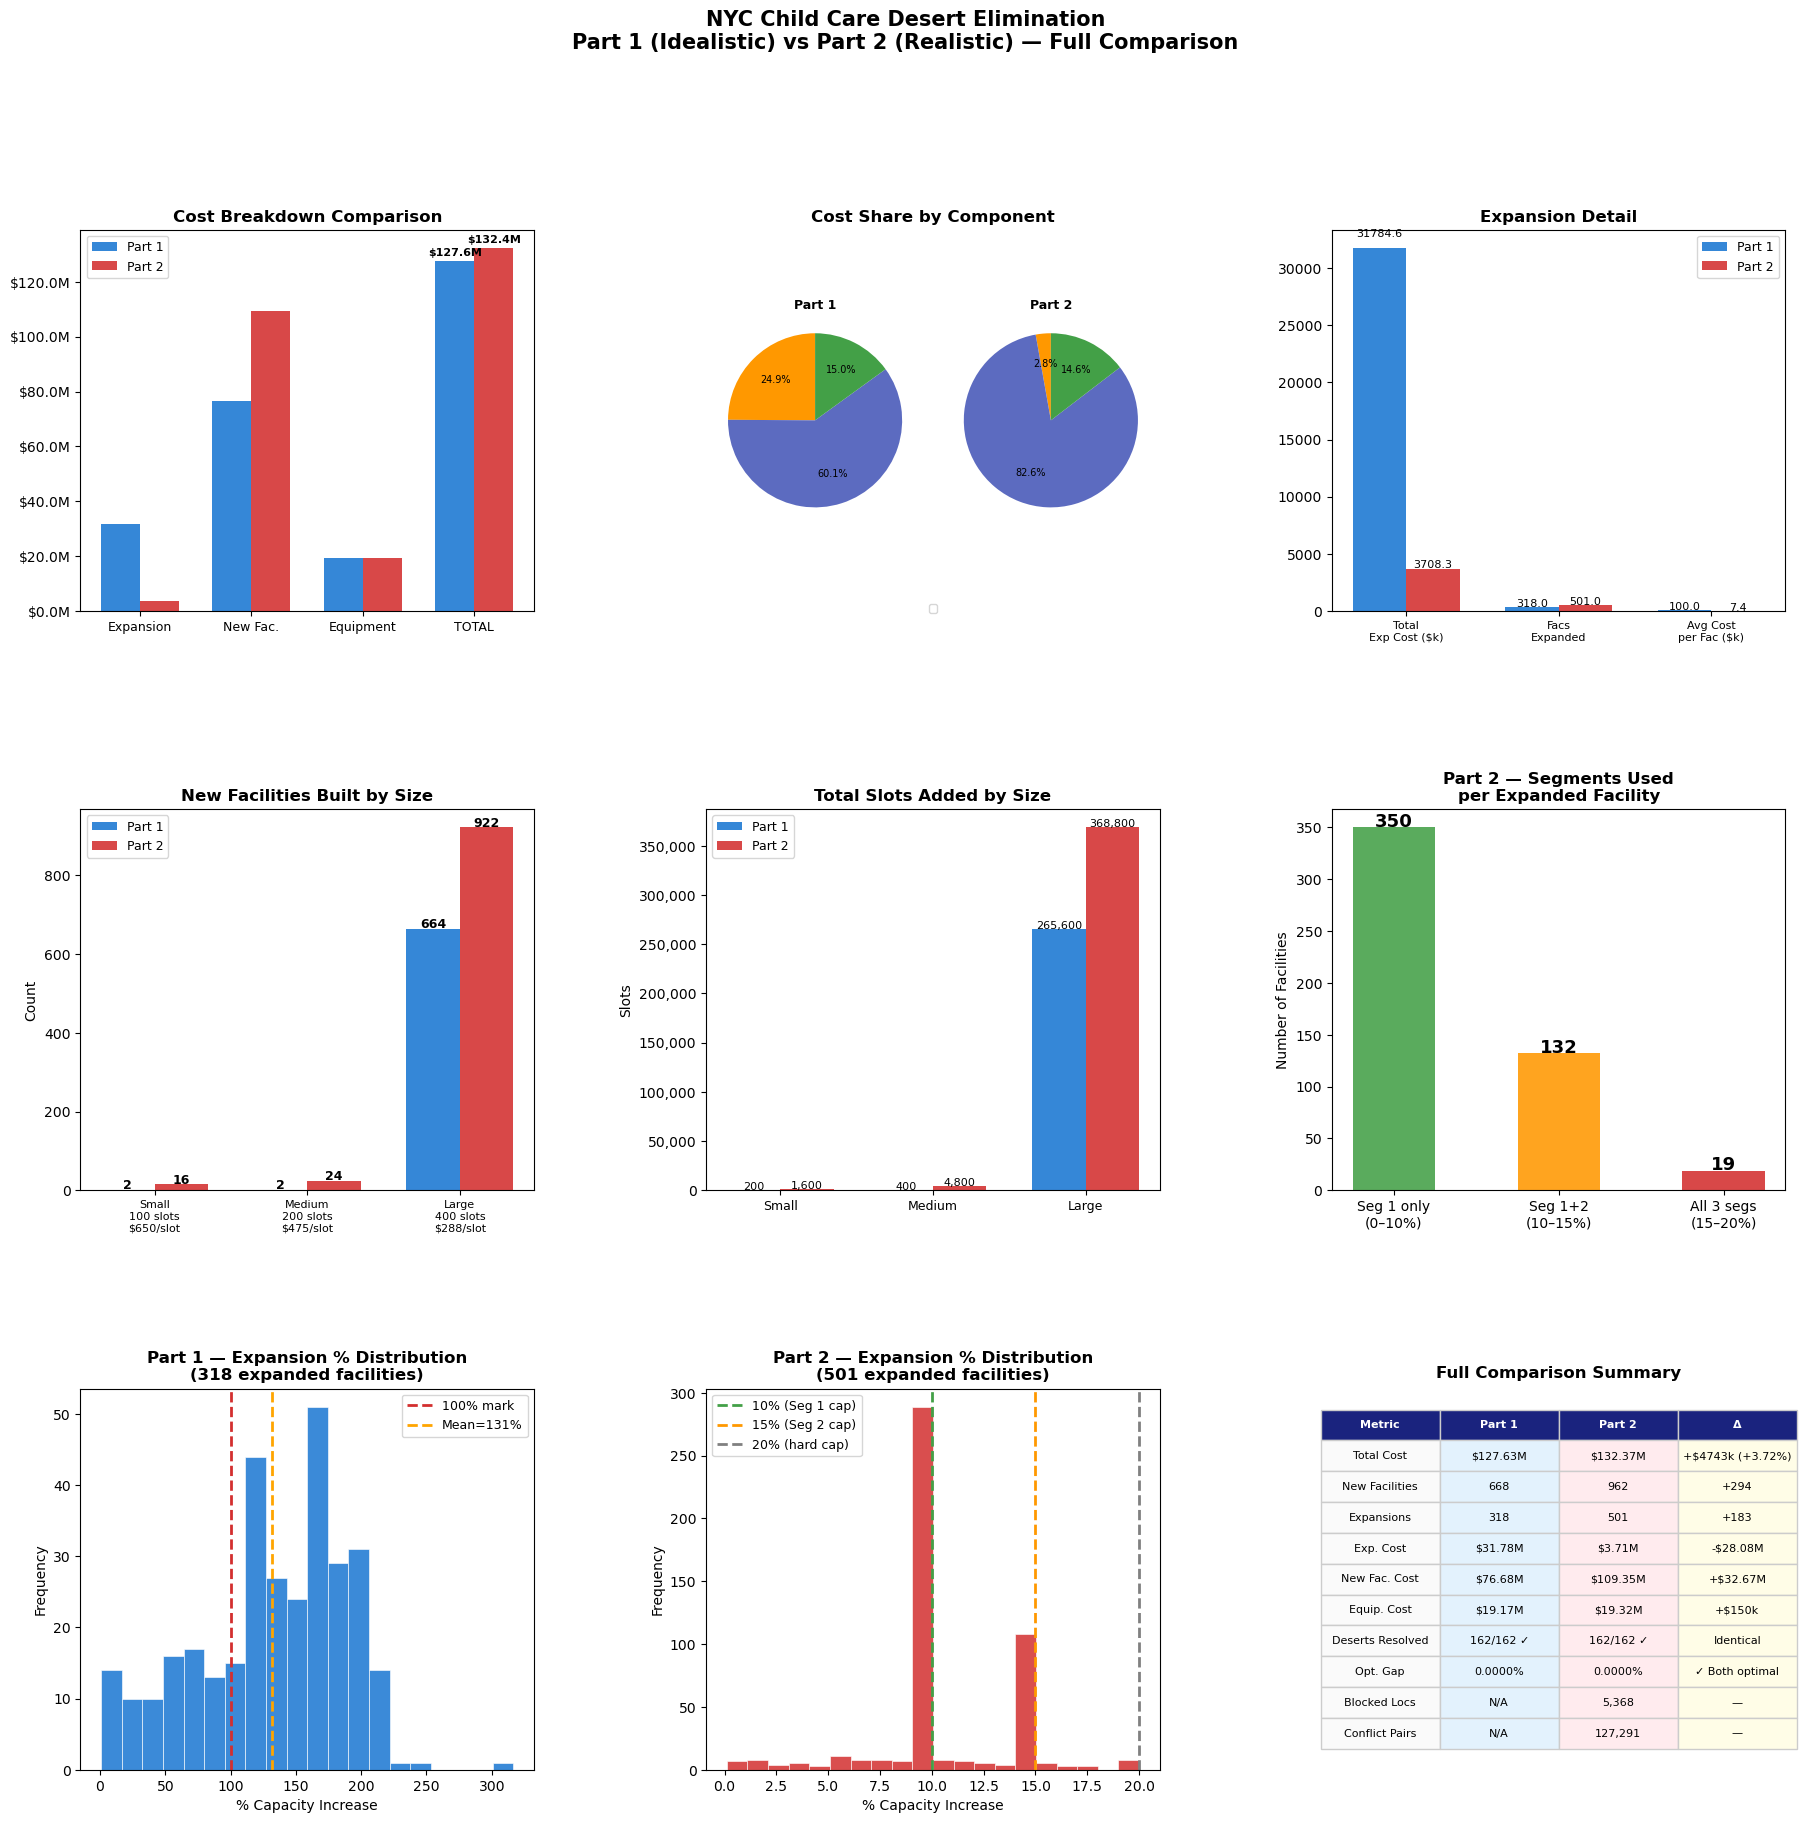

Saved: comparison_results.png


In [40]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

M_fmt   = FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
int_fmt = FuncFormatter(lambda x, _: f'{int(x):,}')
P1 = '#1976D2'; P2 = '#D32F2F'; BAR = 0.35

fig = plt.figure(figsize=(22, 20))
fig.suptitle(
    'NYC Child Care Desert Elimination\n'
    'Part 1 (Idealistic) vs Part 2 (Realistic) — Full Comparison',
    fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

# ── Plot 1: Cost Breakdown ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0,0])
xp = np.arange(4)
b1 = ax1.bar(xp-BAR/2, [p1_exp,p1_new,p1_eq,p1_total], BAR, label='Part 1', color=P1, alpha=0.88)
b2 = ax1.bar(xp+BAR/2, [p2_exp,p2_new,p2_eq,p2_total], BAR, label='Part 2', color=P2, alpha=0.88)
ax1.set_xticks(xp); ax1.set_xticklabels(['Expansion','New Fac.','Equipment','TOTAL'], fontsize=9)
ax1.set_title('Cost Breakdown Comparison', fontweight='bold')
ax1.yaxis.set_major_formatter(M_fmt); ax1.legend(fontsize=9)
for bar, v in [(b1[-1],p1_total),(b2[-1],p2_total)]:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
             f'${v/1e6:.1f}M', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Plot 2: Cost Share Pies ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0,1]); ax2.axis('off')
ax2a = ax2.inset_axes([0.0,0.05,0.48,0.90])
ax2b = ax2.inset_axes([0.52,0.05,0.48,0.90])
colors_pie = ['#FF9800','#5C6BC0','#43A047']
ax2a.pie([p1_exp,p1_new,p1_eq], colors=colors_pie, startangle=90,
         autopct='%1.1f%%', textprops={'fontsize':7}, pctdistance=0.65)
ax2a.set_title('Part 1', fontsize=9, fontweight='bold', pad=2)
ax2b.pie([p2_exp,p2_new,p2_eq], colors=colors_pie, startangle=90,
         autopct='%1.1f%%', textprops={'fontsize':7}, pctdistance=0.65)
ax2b.set_title('Part 2', fontsize=9, fontweight='bold', pad=2)
ax2.legend(['Expansion','New Fac.','Equipment'],
           loc='lower center', fontsize=8, bbox_to_anchor=(0.5,-0.02), ncol=3)
ax2.set_title('Cost Share by Component', fontweight='bold', y=1.0)

# ── Plot 3: Expansion Detail ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0,2])
p1_em = [p1_exp/1e3, p1_n_exp, p1_exp/p1_n_exp/1e3]
p2_em = [p2_exp/1e3, p2_n_exp, p2_exp/p2_n_exp/1e3]
xp3 = np.arange(3)
ax3.bar(xp3-BAR/2, p1_em, BAR, label='Part 1', color=P1, alpha=0.88)
ax3.bar(xp3+BAR/2, p2_em, BAR, label='Part 2', color=P2, alpha=0.88)
ax3.set_xticks(xp3)
ax3.set_xticklabels(['Total\nExp Cost ($k)','Facs\nExpanded','Avg Cost\nper Fac ($k)'], fontsize=8)
ax3.set_title('Expansion Detail', fontweight='bold'); ax3.legend(fontsize=9)
for i,(v1,v2) in enumerate(zip(p1_em,p2_em)):
    ax3.text(i-BAR/2, v1*1.03, f'{v1:.1f}', ha='center', fontsize=8)
    ax3.text(i+BAR/2, v2*1.03, f'{v2:.1f}', ha='center', fontsize=8)

# ── Plot 4: New Facilities by Size ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1,0])
p1_sc = [int(p1_built[p1_built['size']==s]['count'].sum()) for s in ['S','M','L']]
p2_sc = [len(p2_built[p2_built['size']==s]) for s in ['S','M','L']]
xp4 = np.arange(3)
b4a = ax4.bar(xp4-BAR/2, p1_sc, BAR, label='Part 1', color=P1, alpha=0.88)
b4b = ax4.bar(xp4+BAR/2, p2_sc, BAR, label='Part 2', color=P2, alpha=0.88)
ax4.set_xticks(xp4)
ax4.set_xticklabels(['Small\n100 slots\n$650/slot',
                     'Medium\n200 slots\n$475/slot',
                     'Large\n400 slots\n$288/slot'], fontsize=8)
ax4.set_title('New Facilities Built by Size', fontweight='bold')
ax4.set_ylabel('Count'); ax4.legend(fontsize=9)
for i,(v1,v2) in enumerate(zip(p1_sc,p2_sc)):
    ax4.text(i-BAR/2, v1+2, str(v1), ha='center', fontsize=9, fontweight='bold')
    ax4.text(i+BAR/2, v2+2, str(v2), ha='center', fontsize=9, fontweight='bold')

# ── Plot 5: Slots Added by Size ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1,1])
p1_ss = [int(p1_built[p1_built['size']==s]['count'].sum())*sl
         for s,sl in zip(['S','M','L'],[100,200,400])]
p2_ss = [int(p2_built[p2_built['size']==s]['total_slots'].sum()) if not p2_built.empty else 0
         for s in ['S','M','L']]
xp5 = np.arange(3)
ax5.bar(xp5-BAR/2, p1_ss, BAR, label='Part 1', color=P1, alpha=0.88)
ax5.bar(xp5+BAR/2, p2_ss, BAR, label='Part 2', color=P2, alpha=0.88)
ax5.set_xticks(xp5); ax5.set_xticklabels(['Small','Medium','Large'], fontsize=9)
ax5.set_title('Total Slots Added by Size', fontweight='bold')
ax5.set_ylabel('Slots'); ax5.yaxis.set_major_formatter(int_fmt); ax5.legend(fontsize=9)
for i,(v1,v2) in enumerate(zip(p1_ss,p2_ss)):
    ax5.text(i-BAR/2, v1+200, f'{v1:,}', ha='center', fontsize=8)
    ax5.text(i+BAR/2, v2+200, f'{v2:,}', ha='center', fontsize=8)

# ── Plot 6: Part 2 Segment Usage Breakdown ────────────────────────────────────
ax6 = fig.add_subplot(gs[1,2])
seg_counts = [
    (p2_expansions['seg2']==0).sum(),
    ((p2_expansions['seg2']>0) & (p2_expansions['seg3']==0)).sum(),
    (p2_expansions['seg3']>0).sum()
]
seg_labels = ['Seg 1 only\n(0–10%)','Seg 1+2\n(10–15%)','All 3 segs\n(15–20%)']
bars6 = ax6.bar(seg_labels, seg_counts,
                color=['#43A047','#FF9800','#D32F2F'], alpha=0.88, width=0.5)
ax6.set_title('Part 2 — Segments Used\nper Expanded Facility', fontweight='bold')
ax6.set_ylabel('Number of Facilities')
for bar, v in zip(bars6, seg_counts):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(v), ha='center', fontsize=13, fontweight='bold')

# ── Plot 7: Part 1 Expansion % Distribution ───────────────────────────────────
ax7 = fig.add_subplot(gs[2,0])
ax7.hist(p1_expansions['pct_increase'], bins=20,
         color=P1, alpha=0.85, edgecolor='white', linewidth=0.5)
ax7.axvline(100, color=P2, linestyle='--', linewidth=2, label='100% mark')
ax7.axvline(p1_expansions['pct_increase'].mean(), color='orange',
            linestyle='--', linewidth=2,
            label=f"Mean={p1_expansions['pct_increase'].mean():.0f}%")
ax7.set_title(f'Part 1 — Expansion % Distribution\n({p1_n_exp} expanded facilities)',
              fontweight='bold')
ax7.set_xlabel('% Capacity Increase'); ax7.set_ylabel('Frequency')
ax7.legend(fontsize=9)

# ── Plot 8: Part 2 Expansion % Distribution ───────────────────────────────────
ax8 = fig.add_subplot(gs[2,1])
ax8.hist(p2_expansions['pct'], bins=20,          # ← 'pct' confirmed
         color=P2, alpha=0.85, edgecolor='white', linewidth=0.5)
ax8.axvline(10, color='#43A047', linestyle='--', linewidth=2, label='10% (Seg 1 cap)')
ax8.axvline(15, color='#FF9800', linestyle='--', linewidth=2, label='15% (Seg 2 cap)')
ax8.axvline(20, color='gray',    linestyle='--', linewidth=2, label='20% (hard cap)')
ax8.set_title(f'Part 2 — Expansion % Distribution\n({p2_n_exp} expanded facilities)',
              fontweight='bold')
ax8.set_xlabel('% Capacity Increase'); ax8.set_ylabel('Frequency')
ax8.legend(fontsize=9)

# ── Plot 9: Summary Table ─────────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[2,2])
ax9.axis('off')
rows_tbl = [
    ['Total Cost',       f'${p1_total/1e6:.2f}M',  f'${p2_total/1e6:.2f}M',
     f'+${cost_diff/1e3:.0f}k (+{cost_diff_pct:.2f}%)'],
    ['New Facilities',   f'{p1_n_fac:,}',            f'{p2_n_fac:,}',
     f'+{p2_n_fac-p1_n_fac}'],
    ['Expansions',       f'{p1_n_exp}',              f'{p2_n_exp}',
     f'+{p2_n_exp-p1_n_exp}'],
    ['Exp. Cost',        f'${p1_exp/1e6:.2f}M',     f'${p2_exp/1e6:.2f}M',
     f'-${(p1_exp-p2_exp)/1e6:.2f}M'],
    ['New Fac. Cost',    f'${p1_new/1e6:.2f}M',     f'${p2_new/1e6:.2f}M',
     f'+${(p2_new-p1_new)/1e6:.2f}M'],
    ['Equip. Cost',      f'${p1_eq/1e6:.2f}M',      f'${p2_eq/1e6:.2f}M',
     f'+${(p2_eq-p1_eq)/1e3:.0f}k'],
    ['Deserts Resolved', '162/162 ✓',               '162/162 ✓',  'Identical'],
    ['Opt. Gap',         '0.0000%',                  '0.0000%',    '✓ Both optimal'],
    ['Blocked Locs',     'N/A',                      f'{len(blocked):,}', '—'],
    ['Conflict Pairs',   'N/A',                      f'{len(conflict_pairs):,}', '—'],
]
tbl = ax9.table(cellText=rows_tbl,
                colLabels=['Metric','Part 1','Part 2','Δ'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.05, 1.85)
for (r,c), cell in tbl.get_celld().items():
    if r==0:
        cell.set_facecolor('#1a237e')
        cell.set_text_props(color='white', fontweight='bold')
    elif c==3: cell.set_facecolor('#fffde7')
    elif c==1: cell.set_facecolor('#e3f2fd')
    elif c==2: cell.set_facecolor('#ffebee')
    else:      cell.set_facecolor('#fafafa')
    cell.set_edgecolor('#cccccc')
ax9.set_title('Full Comparison Summary', fontweight='bold', pad=8)

plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_results.png")